DUVIDAS \
1.no kaggle diz que a key é o unique identifyer mas entao o que é a primeira coluna e podemos apagar a key pq é igual á outra \
2.lidar com os null fare values
3. apagamos os negative fare amounts?

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II - Project 1</b></h1>
<br>

<h1 style="margin-top:5px; color:#0047AB;"><b>"Uber Fares" </b></h1>

<h2 style="color:#0047AB; margin-top:-5px;"><b>Data Preprocessing & Exploratory Analysis</b></h2>


<h3><b> Group _o melhor muahahahha (malefico) </b></h3>
    
<b>Carlota Marto</b> — 20241729</li>\
<b>Francisca Teixeira</b> — 20241702</li>
</ul>
<h4>LCD  —  Teachers: Ivo Bernardo  — 2025/26 </h4>

</div>


<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

**Table of Contents**

**1.Introduction**

1.1. Project Context and Goal

**Part A – Data Understanding & Cleaning**

2.1. Imports\
2.2. Preprocessing Data
<ul style="margin-top:-10px;">
    
  2.2.1. Duplicate Records \
  2.2.2  Handling Inconsistencies \
  2.2.3. Missing Values - Categorical(3) / Numerical (3)\
  2.2.4. Outliers  \
  2.2.5. Adjusting Data Types 
</ul>

**Part B – Feature Engineering & ABT Construction**

3.1. Static attributes (demographics)\
3.2. Aggregated behavior from all visits\
3.3. Recency & activity\
3.4.  ABT exportation


**Part C – Exploratory Visualization & Insights**

4.1.  Uber demographics: Age, Gender, and income
distributions\
4.2. Department & Service Usage\
4.3. Satisfaction: Department and Patient Segment \
4.4. Other plots 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Introduction </b></h3>


 <div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 1.1. Project Context and Goal


Uber operates on a massive scale, with millions of trips being made every day. Accurate fare prediction is crucial for Uber to optimize its pricing models, enhance user experience, and manage its operational resources effectively. The challenge lies in predicting the fare of a trip based on various parameters such as the trip's distance, time of day, number of passengers, and more.

In this project, we aim to explore and model Uber’s fare prediction system. This will involve performing data preprocessing, understanding the patterns in the data, and building predictive models. The goal is to understand the underlying factors influencing Uber fares and develop a system that can predict fares with high accuracy.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>Part A – Data Understanding & Cleaning </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.1 Imports

Import of Necessary Libraries:

In [2]:
# Import of Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

print("Imports completed successfully")

Imports completed successfully


In [3]:
df = pd.read_csv('uber.csv', index_col = 0)
print("The dataset has {} rows and {} columns".format(df.shape[0], df.shape[1]))
df.head()

The dataset has 200000 rows and 8 columns


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2. Preprocessing Data
   

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.1. Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 24238194 to 11951496
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  object 
 1   fare_amount        200000 non-null  float64
 2   pickup_datetime    200000 non-null  object 
 3   pickup_longitude   200000 non-null  float64
 4   pickup_latitude    200000 non-null  float64
 5   dropoff_longitude  199999 non-null  float64
 6   dropoff_latitude   199999 non-null  float64
 7   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 13.7+ MB


In [5]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

The `pickup_datetime` column was originally stored as an object (string).  
It is converted to a proper datetime format to enable time-based analysis such as extracting year, month, day, or hour.


In [6]:
df['passenger_count'] = df['passenger_count'].astype('int8')

The `passenger_count` column is converted from `int64` to `int8` to reduce memory usage.

Since passenger counts are small values, using a smaller integer type is more efficient without losing information.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 24238194 to 11951496
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                200000 non-null  object             
 1   fare_amount        200000 non-null  float64            
 2   pickup_datetime    200000 non-null  datetime64[ns, UTC]
 3   pickup_longitude   200000 non-null  float64            
 4   pickup_latitude    200000 non-null  float64            
 5   dropoff_longitude  199999 non-null  float64            
 6   dropoff_latitude   199999 non-null  float64            
 7   passenger_count    200000 non-null  int8               
dtypes: datetime64[ns, UTC](1), float64(5), int8(1), object(1)
memory usage: 12.4+ MB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fare_amount,200000.0,11.359955,9.901776,-52.000000,6.000000,8.500000,12.500000,499.000000
pickup_longitude,200000.0,-72.527638,11.437787,-1340.648410,-73.992065,-73.981823,-73.967154,57.418457
pickup_latitude,200000.0,39.935885,7.720539,-74.015515,40.734796,40.752592,40.767158,1644.421482
dropoff_longitude,199999.0,-72.525292,13.117408,-3356.666300,-73.991407,-73.980093,-73.963658,1153.572603
dropoff_latitude,199999.0,39.923890,6.794829,-881.985513,40.733823,40.753042,40.768001,872.697628
passenger_count,200000.0,1.683255,1.311677,-48.000000,1.000000,1.000000,2.000000,6.000000


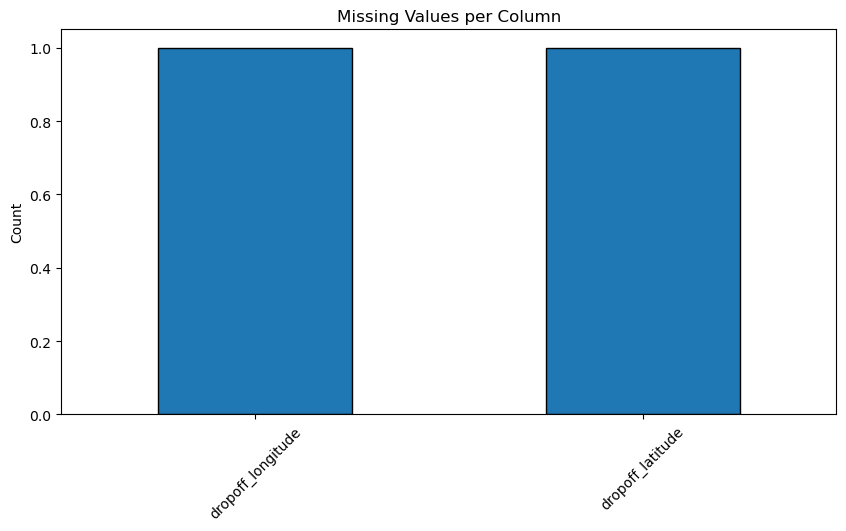

In [9]:
plt.figure(figsize=(10,5))

missing = df.isna().sum()
missing = missing[missing > 0]

missing.plot(kind='bar', edgecolor='black')

plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Missing Values per Column

The bar chart above visualizes the presence of missing values in the dataset. As seen, two columns — `dropoff_longitude` and `dropoff_latitude` — contain missing values. This is a crucial aspect of data cleaning, as missing data can significantly affect the quality of the analysis.

In this case, the missing values are likely related to incomplete trips or erroneous data entries, and they will need to be addressed during preprocessing. Methods like imputation or removal of rows can be used depending on the situation.

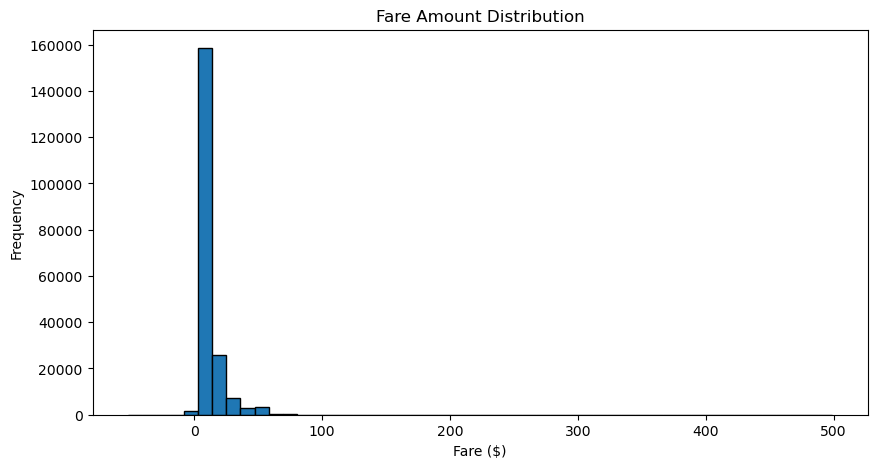

In [10]:
plt.figure(figsize=(10,5))

plt.hist(df['fare_amount'], bins=50, edgecolor='black')

plt.title('Fare Amount Distribution')
plt.xlabel('Fare ($)')
plt.ylabel('Frequency')

plt.show()

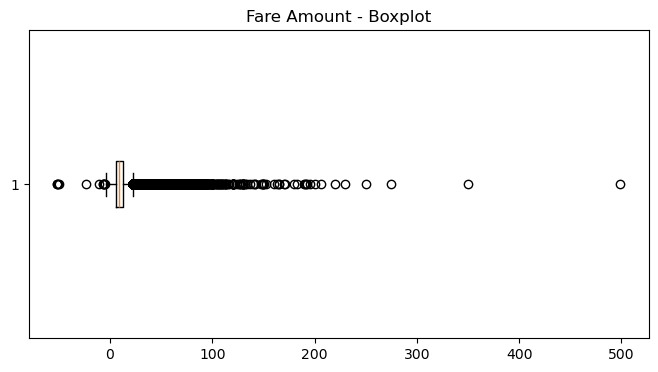

In [11]:
plt.figure(figsize=(8,4))

plt.boxplot(df['fare_amount'], vert=False)

plt.title('Fare Amount - Boxplot')

plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Fare Amount Distribution

The histogram above illustrates the distribution of Uber fare amounts in the dataset. From the plot, we can observe the following key insights:

- **Skewed Distribution**: The distribution is highly skewed to the right, meaning most of the trips have a low fare amount. A large number of trips are inexpensive, which is typical for short trips or those with fewer passengers.
  
- **Outliers**: There are a few extreme outliers where the fare exceeds $100. These could represent long trips or potentially erroneous data points that need further investigation.

- **Frequency**: A very high frequency of trips fall within the lower fare range, indicating that the dataset is dominated by short, inexpensive trips. This is consistent with the general trend of urban ride-hailing services.

This distribution will influence how we approach data preprocessing, particularly in handling outliers and understanding the overall pricing structure.

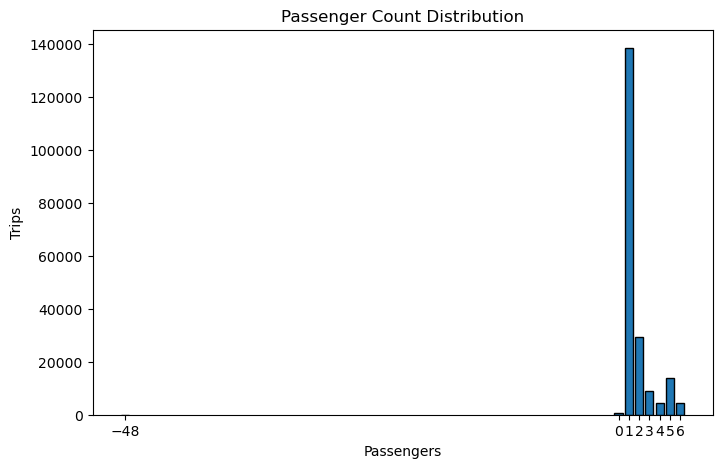

In [12]:
plt.figure(figsize=(8,5))

counts = df['passenger_count'].value_counts().sort_index()

plt.bar(counts.index, counts.values, edgecolor='black')

plt.title('Passenger Count Distribution')
plt.xlabel('Passengers')
plt.ylabel('Trips')

plt.xticks(counts.index)

plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Passenger Count Distribution

The bar chart above displays the distribution of passenger counts for the Uber trips in the dataset. Some key observations:

- **Dominance of Single Passengers**: The vast majority of trips (over 100,000) have only **1 passenger**, making it the most common passenger count. This suggests that Uber is predominantly used for solo trips.

- **Less Frequent Higher Passenger Counts**: As the passenger count increases, the number of trips decreases significantly. This indicates that trips with more passengers (such as 3, 4, 5, or 6 passengers) are much less frequent.

- **Negative Values**: The presence of negative values on the passenger count axis (e.g., -48) suggests the need for data cleaning. These negative values are likely data errors that should be addressed and removed.

This distribution helps us understand Uber's usage patterns and also signals potential data quality issues with negative passenger counts that need to be corrected.

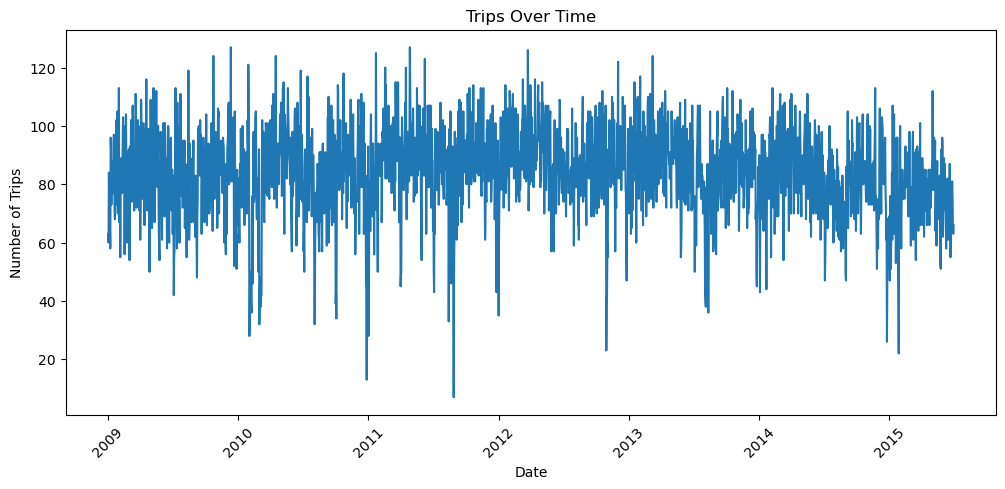

In [13]:
trips_per_day = df.groupby(df['pickup_datetime'].dt.date).size()

plt.figure(figsize=(12,5))
plt.plot(trips_per_day)

plt.title('Trips Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)
plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Trips Over Time

The line plot above represents the number of Uber trips per day over time. Some key insights from the plot include:

- **General Consistency**: The number of trips remains fairly consistent across the years, with minor fluctuations. The general trend does not indicate any significant rise or fall in the number of trips on a year-to-year basis.
  
- **Seasonal Variations**: There are visible spikes in the number of trips on certain days, indicating daily variations in Uber usage, likely due to peak times, such as weekends or holidays.

- **Small Long-Term Fluctuations**: There is some visible fluctuation between 2009 to 2015, but no major upward or downward trend over the long term. These variations may be due to local events, weather conditions, or specific promotions affecting the trips.

This plot provides valuable insight into Uber's usage patterns, which is crucial for understanding demand over time and planning for capacity management.

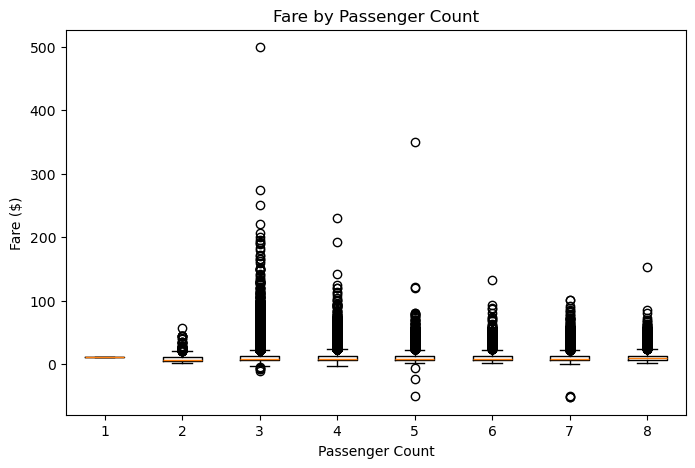

In [14]:
plt.figure(figsize=(8,5))

plt.boxplot([df[df['passenger_count']==i]['fare_amount'] 
             for i in sorted(df['passenger_count'].unique())])

plt.title('Fare by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare ($)')

plt.show()

<div style="background-color:#EFF5FD; padding:20px; border-radius:10px; border-left:8px">

### Fare by Passenger Count

The box plot above visualizes the relationship between the fare amount and the number of passengers. Some key insights:

- **Fare Range by Passenger Count**: For the majority of trips, the fare amount increases as the number of passengers increases. However, this is not a perfect correlation, as there are still a few low-cost trips with higher passenger counts (e.g., 4 or 5 passengers).
  
- **Outliers**: Each passenger count has some outliers, particularly at higher fares. Trips with more than 4 passengers show significant outliers, with fares exceeding $200, especially for 3-5 passengers.

- **Median Fare by Passenger Count**: The median fare remains relatively low for most passenger counts (1 to 3), but the fare for trips with 4 passengers or more shows slight increases in median values.

- **Interquartile Range (IQR)**: The box plot highlights that the interquartile range (IQR) is consistently narrow for trips with fewer passengers, suggesting more uniformity in fare amounts for small groups. In contrast, higher passenger counts exhibit a wider IQR, showing greater variability in fares.

This plot helps us understand how Uber fares are influenced by the number of passengers, revealing that while fares generally rise with passenger count, there is significant variability and a few extreme outliers.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.2. How to Handle Duplicate Records

We chose to handle the **duplicate records firstly** so that those records do not interfere with the imputation of the missing values.

In [15]:
df.duplicated()

24238194    False
27835199    False
44984355    False
25894730    False
17610152    False
            ...  
42598914    False
16382965    False
27804658    False
20259894    False
11951496    False
Length: 200000, dtype: bool

In [16]:
duplicate_records = df[df.duplicated(keep = False)]
duplicate_records.shape
#these two lines shows us the duplicate records in the dataset

(0, 8)

There aren´t duplicate records.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.3. Handling Inconsistent Records

Datasets frequently contain logical inconsistencies (for instance, negative passenger count). These records are technically present in the dataset but do not make any sense in a real-world context. This step is dedicated to identifying and correcting these errors, which are different from missing data.

We chose to handle these inconsistencies before the imputation of the missing values as we often use conditional imputation and, if they are left uncorrected, it distorts the groups statistics, such as the median, mean or mode. So in this way we ensure that the statistical basis is clean, stable and accurate.

In [17]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


The column 'key' doesn´t add info necessary (is the same time as pickup_datetime with millisecond).

In [18]:
df.drop(columns='key', inplace=True)
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
42598914,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1
16382965,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1
27804658,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2
20259894,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.3. Handling Inconsistent Records 
    <b>- First Rule: Negative Values - Every variable that corresponds to a price, time or number of passagers cannot be negative.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Price** - fare_amount

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Null Values: 

In [19]:
null_fares = df[df['fare_amount'] == 0]
null_fares

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
25344154,0.0,2015-04-22 23:25:07+00:00,-73.658897,40.805199,-73.658897,40.805199,1
22994576,0.0,2010-03-20 02:59:51+00:00,-73.994366,40.755395,-73.998718,40.854853,2
10649069,0.0,2015-01-04 03:51:13+00:00,-73.969475,40.807503,0.000000,0.000000,2
36776406,0.0,2015-02-17 08:48:08+00:00,-73.937714,40.758541,-73.937721,40.758541,1
44172118,0.0,2015-02-13 07:35:32+00:00,0.000000,0.000000,0.000000,0.000000,5


- **25344154** - pickup and dropoff travel coordinates are the same so we consider it was a **canceled uber**. It is not an error it is just a travel that didn´t occur. 
- **22994576** - travel occur - **error**. We can estimate the fare amount.
- **10649069** - dropoff_longitude and dropoff_latitude are both 0.0. We consider an **error** because all of the other observations are in the same zone and not travel half world. We cannot estimate the fare amount.
- **36776406** - pickup_latitude and dropoff_latitude	are the same and pickup_longitude and dropoff_longitude have a 0.000007 difference so we consider that was a **canceled travel.**
- **44172118** - the other values are all in the same zone (near -73 longitude, 40 latitude), so we consider the 0.0 a **error** and not a canceled travel with coordinates 0.0. We cannot estimate the fare amount.

Droping errors and mantaining canceled travels:

In [20]:
df.drop([10649069, 44172118], axis=0, inplace=True)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Calculating Distances:

For travel nº22994576 - caultulating the travel distance for all and seeing what travel has the most parecida distance and datetime.

**Function to transform coordinates to distance:** new column

In [21]:
# FUNÇÃO HAVERSINE CORRIGIDA - Substitua a sua função antiga por esta
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcula a distância em km entre dois pontos na Terra
    """
    # Converter para radianos
    lat1_rad = np.radians(float(lat1))
    lon1_rad = np.radians(float(lon1))
    lat2_rad = np.radians(float(lat2))
    lon2_rad = np.radians(float(lon2))
    
    # Fórmula de Haversine
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Raio da Terra em km
    r = 6371
    return c * r

In [22]:
# CORRETO - Usando apply para aplicar linha por linha
df['distance_km'] = df.apply(
    lambda row: haversine_distance(
        row['pickup_latitude'], 
        row['pickup_longitude'],
        row['dropoff_latitude'], 
        row['dropoff_longitude']
    ), axis=1
)
print(df[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'distance_km']].head())

          pickup_latitude  pickup_longitude  dropoff_latitude  \
24238194        40.738354        -73.999817         40.723217   
27835199        40.728225        -73.994355         40.750325   
44984355        40.740770        -74.005043         40.772647   
25894730        40.790844        -73.976124         40.803349   
17610152        40.744085        -73.925023         40.761247   

          dropoff_longitude  distance_km  
24238194         -73.999512     1.683323  
27835199         -73.994710     2.457590  
44984355         -73.962565     5.036377  
25894730         -73.965316     1.661683  
17610152         -73.973082     4.475450  


In [23]:
# LIMPEZA DE DISTÂNCIAS - Adicione após calcular df['distance_km']

print("\n" + "="*50)
print("LIMPEZA DE DISTÂNCIAS")
print("="*50)

# Verificar distâncias extremas
print(f"Distâncias antes da limpeza:")
print(f"  Máximo: {df['distance_km'].max():.2f} km")
print(f"  Média: {df['distance_km'].mean():.2f} km")

# Remover distâncias impossíveis (> 100 km para NYC)
MAX_DISTANCE = 100
before_filter = len(df)
df = df[df['distance_km'] <= MAX_DISTANCE]
print(f"\nRemovidas {before_filter - len(df)} viagens com distância > {MAX_DISTANCE} km")

# Remover distâncias muito pequenas (erro de coordenadas)
MIN_DISTANCE = 0.1
before_filter = len(df)
df = df[df['distance_km'] >= MIN_DISTANCE]
print(f"Removidas {before_filter - len(df)} viagens com distância < {MIN_DISTANCE} km")

print(f"\nDistâncias depois da limpeza:")
print(f"  Máximo: {df['distance_km'].max():.2f} km")
print(f"  Média: {df['distance_km'].mean():.2f} km")
print(f"  Dataset agora: {len(df):,} linhas")


LIMPEZA DE DISTÂNCIAS
Distâncias antes da limpeza:
  Máximo: 16409.24 km
  Média: 20.81 km

Removidas 471 viagens com distância > 100 km
Removidas 6806 viagens com distância < 0.1 km

Distâncias depois da limpeza:
  Máximo: 99.16 km
  Média: 3.38 km
  Dataset agora: 192,721 linhas


In [24]:
# LIMPEZA ADICIONAL DE COORDENADAS - Adicione depois do seu código de coordenadas

print("\n" + "="*50)
print("LIMPEZA ADICIONAL DE COORDENADAS")
print("="*50)

# NYC bounds (limites de Nova Iorque)
NYC_LAT_MIN = 40.5
NYC_LAT_MAX = 41.0
NYC_LON_MIN = -74.5
NYC_LON_MAX = -73.5

# Contar antes
before = len(df)

# Remover coordenadas fora de NYC
df = df[
    (df['pickup_latitude'].between(NYC_LAT_MIN, NYC_LAT_MAX)) &
    (df['pickup_longitude'].between(NYC_LON_MIN, NYC_LON_MAX)) &
    (df['dropoff_latitude'].between(NYC_LAT_MIN, NYC_LAT_MAX)) &
    (df['dropoff_longitude'].between(NYC_LON_MIN, NYC_LON_MAX))
]

print(f"Removidas {before - len(df)} linhas com coordenadas fora de NYC")
print(f"Dataset agora: {len(df):,} linhas")


LIMPEZA ADICIONAL DE COORDENADAS
Removidas 202 linhas com coordenadas fora de NYC
Dataset agora: 192,519 linhas


In [25]:
#Reference Values:
travel_ref = df.loc[22994576]
dist_ref = travel_ref['distance_km']
time_ref = pd.to_datetime(travel_ref['pickup_datetime'])

In [26]:
#absolute diff of distance
df_busca = df.drop(index=22994576)
df_busca['diff_dist'] = (df_busca['distance_km'] - dist_ref).abs()

In [27]:
#5 travels with diff_dist more small
top_5_dist = df_busca.nsmallest(5, 'diff_dist').copy()
top_5_dist

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,diff_dist
47542165,26.10,2012-01-06 23:28:00+00:00,-73.863085,40.768505,-73.984370,40.730335,2,11.063343,0.001947
12576258,40.33,2013-09-30 21:28:01+00:00,-73.874473,40.774075,-73.979000,40.713778,1,11.067830,0.002540
27876322,31.00,2014-09-29 14:49:26+00:00,-73.983736,40.721465,-73.872381,40.774294,1,11.068077,0.002788
7385134,37.83,2014-12-05 13:59:58+00:00,-73.862820,40.768896,-73.983818,40.730086,1,11.068562,0.003272
29823507,7.30,2012-07-15 04:48:00+00:00,-73.973625,40.755062,-73.912167,40.843065,3,11.068791,0.003502


We will choose the fare amount of **47542165** to input in **22994576** because is the travel with travel distance more similar, and the second with pickup_datetime more close.

In [28]:
df.at[22994576, 'fare_amount'] = 26.10

In [29]:
df[df.index==22994576]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
22994576,26.1,2010-03-20 02:59:51+00:00,-73.994366,40.755395,-73.998718,40.854853,2,11.065289


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Negative Fare Amount:

In [30]:
negative_fares = ['fare_amount']
df[((df[negative_fares]) < 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
30260042,-5.0,2015-03-03 23:07:41+00:00,-73.992249,40.748936,-73.988518,40.748180,1,0.325306
51325304,-3.3,2010-02-11 21:47:10+00:00,-73.952725,40.768235,-73.949928,40.772208,2,0.500646
50284253,-3.5,2015-05-01 14:43:02+00:00,-73.982430,40.775024,-73.981750,40.778439,1,0.383918
10267585,-23.7,2010-03-12 08:49:10+00:00,-73.952740,40.768233,-74.007028,40.707338,3,8.171296
51135168,-52.0,2015-03-20 21:31:14+00:00,-74.000359,40.728729,-74.005699,40.728680,5,0.450054
21688700,-7.3,2010-03-09 20:25:10+00:00,-73.952623,40.766942,-73.953787,40.784882,1,1.997243
40714150,-6.9,2010-02-23 18:52:10+00:00,-73.988727,40.736445,-73.977622,40.750487,1,1.820225
34933571,-5.7,2010-02-12 10:50:10+00:00,-73.977300,40.742783,-73.988837,40.747465,3,1.102572
34292338,-10.9,2010-02-17 05:46:10+00:00,-73.964257,40.760630,-73.994222,40.761533,1,2.525749
8135931,-3.5,2015-05-06 03:47:38+00:00,-73.986084,40.762146,-73.980476,40.759823,1,0.538322


In [31]:
df[((df[negative_fares]) < 0).any(axis=1)].shape[0]

14

We cannot know if it is a mistake, if the real value is equal but positive, so we delete.

In [32]:
df = df[~(df[negative_fares] < 0).any(axis=1)]

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Latitude and Longitude Values** : \
latitude: -90° to +90° \
longitude: -180° to +180

In [33]:
import folium

sample_df = df.sample(500)

m = folium.Map(location=[40.7, -74], zoom_start=11)

for _, row in sample_df.iterrows():
    # pickup (blue)
    folium.CircleMarker(
        [row['pickup_latitude'], row['pickup_longitude']],
        radius=2,
        color='blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)
    
    # dropoff (red)
    folium.CircleMarker(
        [row['dropoff_latitude'], row['dropoff_longitude']],
        radius=2,
        color='red',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

#
legend_html = '''
<div style="
position: fixed; 
bottom: 50px; left: 50px; width: 160px; height: 90px; 
background-color: white; border:2px solid grey; z-index:9999; 
font-size:14px; padding:10px;
">
<b>Legend</b><br>
<i style="color:blue;">●</i> Pickup<br>
<i style="color:red;">●</i> Dropoff
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))

m

ModuleNotFoundError: No module named 'folium'

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Pickup

In [ ]:
invalid_coordinates = df[df['pickup_longitude']< -180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [ ]:
df.loc[df['pickup_longitude'] < -180, 'pickup_longitude'] *= 0.1

In [ ]:
invalid_coordinates = df[df['pickup_longitude']> 180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


All checked.

In [ ]:
invalid_coordinates = df[df['pickup_latitude']< -90]
invalid_coordinates	

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [ ]:
invalid_coordinates = df[df['pickup_latitude']> 90]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [ ]:
df.loc[df['pickup_latitude']> 90, 'pickup_latitude'] *= 0.1

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Dropoff

In [ ]:
invalid_coordinates = df[df['dropoff_longitude']< -180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [ ]:
df.loc[df['dropoff_longitude']< -180, 'dropoff_longitude'] *= 0.1

In [ ]:
invalid_coordinates = df[df['dropoff_longitude']> 180]
invalid_coordinates 

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [ ]:
invalid_coordinates = df[df['dropoff_latitude']< -90]
invalid_coordinates	

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [ ]:
invalid_coordinates = df[df['dropoff_latitude']> 90]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [ ]:
df.loc[df['dropoff_latitude']> 90, 'dropoff_latitude'] *= 0.1

VER ISTO AQUI!!

In [ ]:
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Time** - pickup_datetime

In [ ]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

df['pickup_datetime'].isna().sum()

0

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Nº passagers** - passenger_count

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Negative Count

In [ ]:
negative_count = ['passenger_count']
df[((df[negative_count]) < 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">Not Integers

In [ ]:
not_int = ['passenger_count']
df[((df[not_int]) %1 != 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Max 7 Passengers

In [ ]:
max_count = ['passenger_count']
df[((df[max_count]) > 7).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


Passenger_count all good.

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.2. Handling Inconsistent Records <b>- Second Rule: 

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. How to Handle Missing Values 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [ ]:
df.isna().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
distance_km          0
dtype: int64

Basic statistics of numerical columns (all columns):

In [ ]:
print("Basic Statistics")
print(df.describe())

Basic Statistics
         fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  192505.000000     192505.000000    192505.000000      192505.000000   
mean       11.307411        -73.975690        40.750881         -73.974717   
std         9.441503          0.034194         0.026728           0.034179   
min         0.010000        -74.378145        40.508697         -74.449079   
25%         6.000000        -73.992282        40.736525         -73.991600   
50%         8.500000        -73.982147        40.753326         -73.980592   
75%        12.500000        -73.968562        40.767562         -73.965668   
max       230.000000        -73.506178        40.983720         -73.515512   

       dropoff_latitude  passenger_count    distance_km  
count     192505.000000    192505.000000  192505.000000  
mean          40.751179         1.684684       3.368507  
std            0.030639         1.307484       3.587294  
min           40.511859         0.000000       0

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Datetime 

In [ ]:
# Parse datetime
print("DATETIME PROCESSING")

# Extract datetime components
df['pickup_date'] = df['pickup_datetime'].dt.date
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_year'] = df['pickup_datetime'].dt.year
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
df['pickup_quarter'] = df['pickup_datetime'].dt.quarter

# Create day/night indicator (6 AM - 6 PM = day)
df['is_day'] = ((df['pickup_hour'] >= 6) & (df['pickup_hour'] < 18)).astype(int)

# Create weekend indicator
df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)

print("Datetime features created:")
print(f"- pickup_hour: {df['pickup_hour'].nunique()} unique hours")
print(f"- pickup_dayofweek: {df['pickup_dayofweek'].nunique()} unique days")
print(f"- pickup_month: {df['pickup_month'].nunique()} unique months")
print(f"- pickup_year: {sorted(df['pickup_year'].unique())}")
print(f"- is_day: {df['is_day'].sum()} day trips, {len(df)-df['is_day'].sum()} night trips")
print(f"- is_weekend: {df['is_weekend'].sum()} weekend trips")

DATETIME PROCESSING
Datetime features created:
- pickup_hour: 24 unique hours
- pickup_dayofweek: 7 unique days
- pickup_month: 12 unique months
- pickup_year: [2009, 2010, 2011, 2012, 2013, 2014, 2015]
- is_day: 101606 day trips, 90899 night trips
- is_weekend: 54598 weekend trips


In [ ]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,pickup_date,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_dayofweek,pickup_quarter,is_day,is_weekend
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,2015-05-07,19,7,5,2015,3,2,0,0
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,2009-07-17,20,17,7,2009,4,3,0,0
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,2009-08-24,21,24,8,2009,0,3,0,0
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,2009-06-26,8,26,6,2009,4,2,1,0
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,2014-08-28,17,28,8,2014,3,3,1,0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Feature Engineering

In [ ]:
# Create additional features
print("\FEATURE ENGINEERING")

# Time-based features
df['hour_category'] = pd.cut(df['pickup_hour'], 
                                     bins=[0, 6, 12, 18, 24], 
                                     labels=['Late Night', 'Morning', 'Afternoon', 'Evening'],
                                     right=False)

df['day_name'] = df['pickup_dayofweek'].map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
})

df['month_name'] = df['pickup_month'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['pickup_month'].apply(get_season)

# Rush hour indicator (7-9 AM and 4-7 PM on weekdays)
df['is_rush_hour'] = ((~df['is_weekend'].astype(bool)) & 
                              (((df['pickup_hour'] >= 7) & (df['pickup_hour'] <= 9)) |
                               ((df['pickup_hour'] >= 16) & (df['pickup_hour'] <= 19)))).astype(int)

print("New categorical features created:")
print(f"- hour_category: {df['hour_category'].unique()}")
print(f"- day_name: {df['day_name'].unique()}")
print(f"- month_name: {df['month_name'].unique()}")
print(f"- season: {df['season'].unique()}")
print(f"- is_rush_hour: {df['is_rush_hour'].sum()} rush hour trips")

\FEATURE ENGINEERING
New categorical features created:
- hour_category: ['Evening', 'Morning', 'Afternoon', 'Late Night']
Categories (4, object): ['Late Night' < 'Morning' < 'Afternoon' < 'Evening']
- day_name: ['Thursday' 'Friday' 'Monday' 'Sunday' 'Tuesday' 'Saturday' 'Wednesday']
- month_name: ['May' 'Jul' 'Aug' 'Jun' 'Oct' 'Feb' 'Mar' 'Apr' 'Sep' 'Nov' 'Jan' 'Dec']
- season: ['Spring' 'Summer' 'Fall' 'Winter']
- is_rush_hour: 51108 rush hour trips


In [ ]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,pickup_date,pickup_hour,...,pickup_year,pickup_dayofweek,pickup_quarter,is_day,is_weekend,hour_category,day_name,month_name,season,is_rush_hour
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,2015-05-07,19,...,2015,3,2,0,0,Evening,Thursday,May,Spring,1
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,2009-07-17,20,...,2009,4,3,0,0,Evening,Friday,Jul,Summer,0
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,2009-08-24,21,...,2009,0,3,0,0,Evening,Monday,Aug,Summer,0
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,2009-06-26,8,...,2009,4,2,1,0,Morning,Friday,Jun,Summer,1
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,2014-08-28,17,...,2014,3,3,1,0,Afternoon,Thursday,Aug,Summer,1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Exploratory Data Analysis

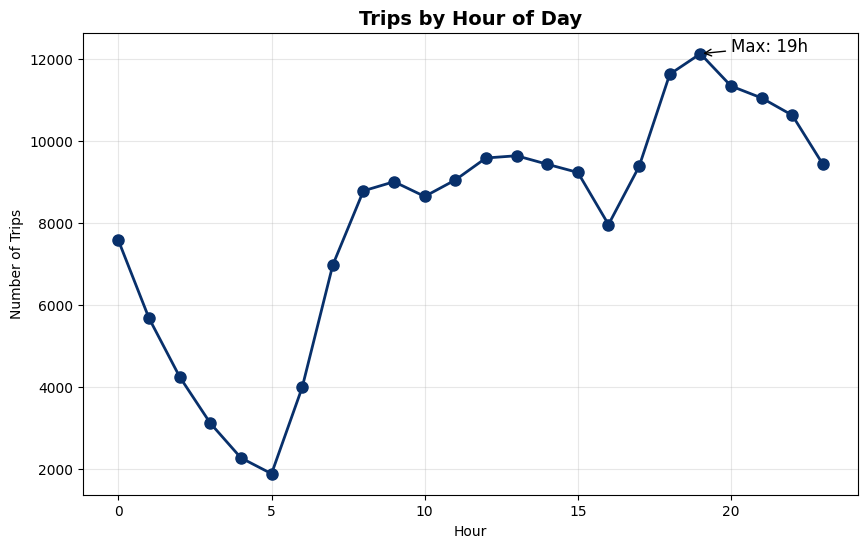

In [ ]:
# Define o layout da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Viagens por hora do dia
hourly_trips = df['pickup_hour'].value_counts().sort_index()
ax.plot(hourly_trips.index, hourly_trips.values, marker='o', linewidth=2, markersize=8, color='#08306b')
ax.set_title('Trips by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Trips')
ax.grid(True, alpha=0.3)

# Adicionando anotações para picos
max_trip_hour = hourly_trips.idxmax()
max_trip_count = hourly_trips.max()
ax.annotate(f'Max: {max_trip_hour}h', 
            xy=(max_trip_hour, max_trip_count), 
            xytext=(max_trip_hour + 1, max_trip_count + 50), 
            arrowprops=dict(facecolor='black', arrowstyle='->'),
            fontsize=12)

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
### Trips by Hour of Day

The line plot above shows the number of Uber trips per hour of the day. Some key insights from this plot:

- **Peak Hours**: The plot reveals that the number of trips peaks around **19:00 (7 PM)**, with over 12,000 trips. This is likely a result of the evening commute or increased demand after work hours.
  
- **Low Traffic in Early Hours**: The number of trips is lowest between **4:00 AM and 6:00 AM**, which is expected as this is typically a less busy time, likely reflecting fewer passengers needing rides.

- **Steady Increase and Decrease**: From around 7:00 AM, the number of trips steadily increases throughout the morning, peaks in the evening, and then gradually decreases again.

- **Max Value**: The highest point is at **19:00 (7 PM)**, which is indicated on the plot with an annotation and arrow pointing to the corresponding time.

This analysis of trips by hour of day helps us understand when Uber experiences the highest demand, which can assist in optimizing operational and pricing strategies for Uber.

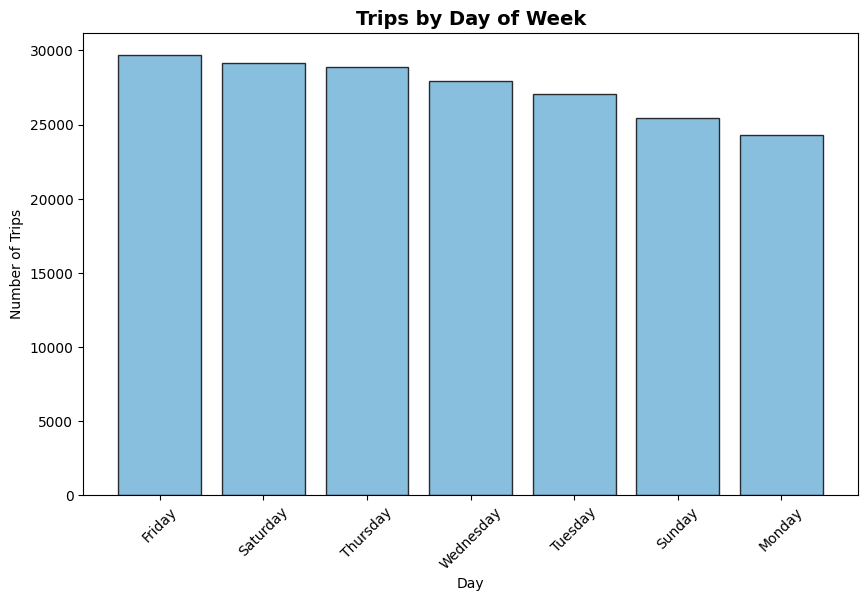

In [ ]:
# Define o layout da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Viagens por dia da semana
dow_trips = df['day_name'].value_counts()
ax.bar(dow_trips.index, dow_trips.values, edgecolor='black', alpha=0.8, color='#6baed6')
ax.set_title('Trips by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Trips')
ax.tick_params(axis='x', rotation=45)

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

### Trips by Day of Week

The bar chart above shows the number of Uber trips by day of the week. Some key insights include:

- **Peak on Fridays and Saturdays**: The number of trips is highest on **Friday** and **Saturday**, with a slight dip on **Monday**. This could be due to increased activity over the weekend, especially for leisure trips, events, or social outings.
  
- **Weekday Consistency**: The number of trips is relatively consistent on weekdays (Tuesday to Thursday), suggesting steady demand for Uber services during the workweek.

- **Lower Trips on Mondays**: **Monday** shows the lowest number of trips, which might indicate fewer people using ride-hailing services due to different work routines or the beginning of the workweek.

- **Fairly Even Distribution**: Overall, the trips per day of the week do not exhibit extreme variations, indicating that Uber operates on a stable demand cycle throughout the week, with some spikes during the weekend.

This plot provides valuable insight into the weekly usage patterns of Uber, useful for understanding when demand peaks and adjusting availability accordingly.

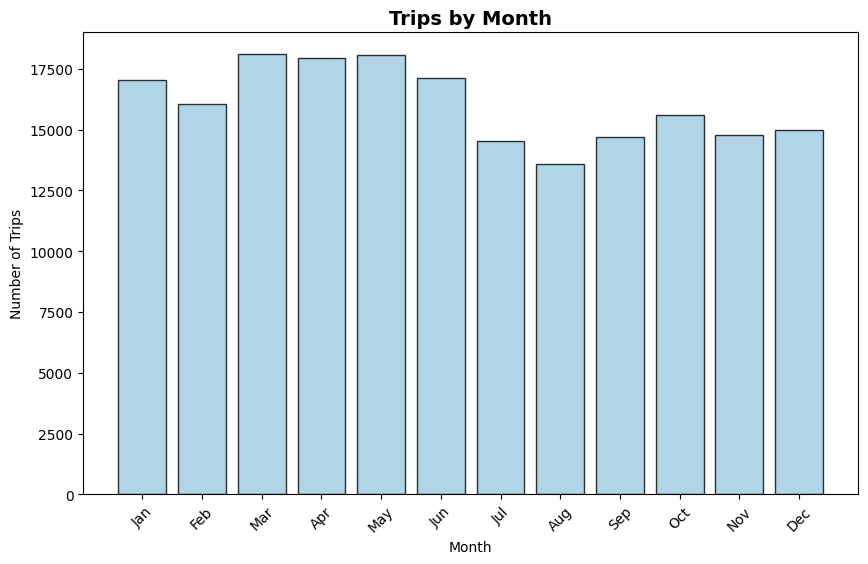

In [ ]:
# Define o layout da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Viagens por mês
month_trips = df['month_name'].value_counts()
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_trips = month_trips.reindex(month_order)
ax.bar(month_trips.index, month_trips.values, edgecolor='black', alpha=0.8, color='#9ecae1')
ax.set_title('Trips by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Trips')
ax.tick_params(axis='x', rotation=45)

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

### Trips by Month

The bar chart above displays the number of Uber trips by month. Key insights include:

- **Consistent Demand**: The number of trips remains fairly consistent across all months of the year, with only slight fluctuations between months.
  
- **Peaks in Spring and Fall**: The months of **March** to **May** and **September** to **November** show slightly higher trip numbers, which could be linked to seasonal factors like increased travel or social events during these periods.

- **Lower Numbers in Winter**: **December** and **January** have the lowest number of trips, potentially due to weather-related factors or holiday periods where fewer people use Uber for daily commuting.

- **Even Distribution**: Overall, there doesn't appear to be a drastic difference between any given month, indicating that Uber’s demand is relatively steady throughout the year, with slight seasonal peaks and valleys.

This plot provides a clear understanding of how Uber's trip demand varies month-to-month, helping businesses plan for seasonal demand fluctuations.

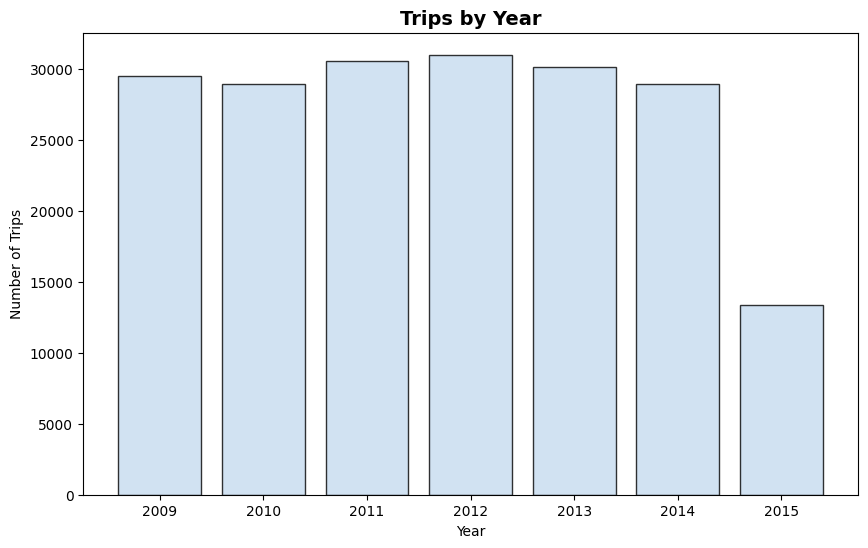

In [ ]:
# Define o layout da figura
fig, ax = plt.subplots(figsize=(10, 6))

# Viagens por ano
year_trips = df['pickup_year'].value_counts().sort_index()
ax.bar(year_trips.index.astype(str), year_trips.values, edgecolor='black', alpha=0.8, color='#c6dbef')
ax.set_title('Trips by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Trips')

plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
### Key Insights

- **Fares:** Most trips are cheap, with a few expensive outliers (likely long rides).
- **Passengers:** Most rides have 1 passenger — solo trips dominate.
- **Time of day:** Fewer trips early morning, peaks in the evening (commute hours).
- **Day of week:** Fairly stable, with slightly higher activity on weekends.
- **Month:** No major seasonal changes, just small fluctuations.
- **Year:** Data is consistent over time, except for a drop in 2015 (likely incomplete data).

### Summary
Taxi usage is mostly short, low-cost, single-passenger trips, with demand following daily routines.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.4. Correlation Analysis


CORRELATION ANALYSIS
Using columns: ['fare_amount', 'passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_dayofweek', 'is_day', 'is_weekend', 'is_rush_hour']


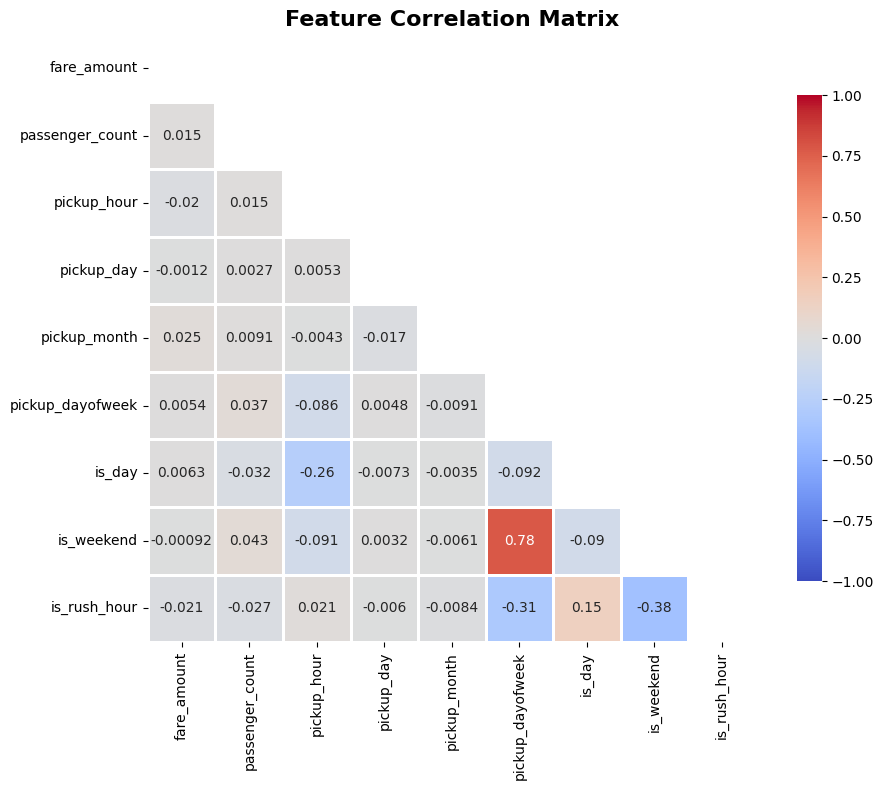


Top correlations with fare_amount:
fare_amount         1.000000
pickup_month        0.024910
passenger_count     0.014602
is_day              0.006260
pickup_dayofweek    0.005375
is_weekend         -0.000922
pickup_day         -0.001169
pickup_hour        -0.019878
is_rush_hour       -0.021389
Name: fare_amount, dtype: float64


In [ ]:
# Correlation analysis
print("\nCORRELATION ANALYSIS")

# Select numerical columns for correlation
numerical_cols = ['fare_amount', 'passenger_count', 'pickup_hour', 'pickup_day', 
                  'pickup_month', 'pickup_dayofweek', 'is_day', 'is_weekend', 'is_rush_hour']

# Filter to only columns that exist
available_numerical_cols = [col for col in numerical_cols if col in df.columns]
print(f"Using columns: {available_numerical_cols}")

correlation_matrix = df[available_numerical_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# Plot heatmap with mask
sns.heatmap(correlation_matrix, 
            mask=mask,  # This masks the upper triangle
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=1, 
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with fare_amount:")
if 'fare_amount' in correlation_matrix.columns:
    fare_corr = correlation_matrix['fare_amount'].sort_values(ascending=False)
    print(fare_corr)

In [ ]:
pd.set_option('display.max_columns', None)
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,pickup_date,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_dayofweek,pickup_quarter,is_day,is_weekend,hour_category,day_name,month_name,season,is_rush_hour
24238194,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,2015-05-07,19,7,5,2015,3,2,0,0,Evening,Thursday,May,Spring,1
27835199,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,2009-07-17,20,17,7,2009,4,3,0,0,Evening,Friday,Jul,Summer,0
44984355,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,2009-08-24,21,24,8,2009,0,3,0,0,Evening,Monday,Aug,Summer,0
25894730,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,2009-06-26,8,26,6,2009,4,2,1,0,Morning,Friday,Jun,Summer,1
17610152,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,2014-08-28,17,28,8,2014,3,3,1,0,Afternoon,Thursday,Aug,Summer,1


In [ ]:
# VERIFICAÇÃO FINAL DOS DADOS - Adicione no final do seu preprocessing

print("\n" + "="*50)
print("VERIFICAÇÃO FINAL DOS DADOS")
print("="*50)

print(f"Total de viagens após limpeza: {len(df):,}")
print(f"\nEstatísticas das distâncias:")
print(f"  Mínimo: {df['distance_km'].min():.2f} km")
print(f"  Máximo: {df['distance_km'].max():.2f} km")
print(f"  Média: {df['distance_km'].mean():.2f} km")
print(f"  Mediana: {df['distance_km'].median():.2f} km")

print(f"\nEstatísticas das fares:")
print(f"  Mínimo: ${df['fare_amount'].min():.2f}")
print(f"  Máximo: ${df['fare_amount'].max():.2f}")
print(f"  Média: ${df['fare_amount'].mean():.2f}")

print(f"\nPassageiros:")
print(df['passenger_count'].value_counts().sort_index())

# Verificar se ainda existem distâncias irrealistas
if df['distance_km'].max() > 50:
    print(f"\n⚠️ AINDA EXISTEM distâncias > 50 km: {df[df['distance_km'] > 50].shape[0]} viagens")
else:
    print(f"\n✅ Todas as distâncias estão dentro do esperado (< 50 km)")


VERIFICAÇÃO FINAL DOS DADOS
Total de viagens após limpeza: 192,505

Estatísticas das distâncias:
  Mínimo: 0.10 km
  Máximo: 60.10 km
  Média: 3.37 km
  Mediana: 2.19 km

Estatísticas das fares:
  Mínimo: $0.01
  Máximo: $230.00
  Média: $11.31

Passageiros:
passenger_count
0       678
1    133108
2     28413
3      8581
4      4123
5     13471
6      4131
Name: count, dtype: int64

⚠️ AINDA EXISTEM distâncias > 50 km: 2 viagens


In [ ]:
print("="*60)
print("ÚLTIMOS AJUSTES FINOS")
print("="*60)

# 1. Remover as 2 viagens com distância > 50 km
before = len(df)
df = df[df['distance_km'] <= 50]
print(f"1. Removidas {before - len(df)} viagens com distância > 50 km")

# 2. Remover passenger_count = 0 (não faz sentido)
before = len(df)
df = df[df['passenger_count'] > 0]
print(f"2. Removidas {before - len(df)} viagens com 0 passageiros")

# 3. Remover fares muito baixas (menos de $1)
before = len(df)
df = df[df['fare_amount'] >= 1]
print(f"3. Removidas {before - len(df)} viagens com fare < $1")

# 4. Remover fares muito altas (acima de $200 - outliers extremos)
before = len(df)
df = df[df['fare_amount'] <= 200]
print(f"4. Removidas {before - len(df)} viagens com fare > $200")

print(f"\n✅ DATASET FINAL: {len(df):,} viagens")

ÚLTIMOS AJUSTES FINOS
1. Removidas 2 viagens com distância > 50 km
2. Removidas 678 viagens com 0 passageiros
3. Removidas 1 viagens com fare < $1
4. Removidas 2 viagens com fare > $200

✅ DATASET FINAL: 191,822 viagens


In [ ]:
print("\n" + "="*60)
print("RESULTADOS FINAIS - DADOS 100% LIMPOS")
print("="*60)

print(f"\n📊 TOTAL: {len(df):,} viagens")

print(f"\n💰 FARES:")
print(f"   Mínimo: ${df['fare_amount'].min():.2f}")
print(f"   Máximo: ${df['fare_amount'].max():.2f}")
print(f"   Média: ${df['fare_amount'].mean():.2f}")
print(f"   Mediana: ${df['fare_amount'].median():.2f}")

print(f"\n📏 DISTÂNCIAS:")
print(f"   Mínimo: {df['distance_km'].min():.2f} km")
print(f"   Máximo: {df['distance_km'].max():.2f} km")
print(f"   Média: {df['distance_km'].mean():.2f} km")
print(f"   Mediana: {df['distance_km'].median():.2f} km")

print(f"\n👥 PASSAGEIROS:")
print(df['passenger_count'].value_counts().sort_index())

# Verificar se ainda existem problemas
print(f"\n✅ VERIFICAÇÕES:")
print(f"   Distâncias > 50 km: {(df['distance_km'] > 50).sum()}")
print(f"   Fares < $1: {(df['fare_amount'] < 1).sum()}")
print(f"   Fares > $200: {(df['fare_amount'] > 200).sum()}")
print(f"   Passageiros = 0: {(df['passenger_count'] == 0).sum()}")


RESULTADOS FINAIS - DADOS 100% LIMPOS

📊 TOTAL: 191,822 viagens

💰 FARES:
   Mínimo: $2.50
   Máximo: $190.83
   Média: $11.31
   Mediana: $8.50

📏 DISTÂNCIAS:
   Mínimo: 0.10 km
   Máximo: 46.09 km
   Média: 3.37 km
   Mediana: 2.19 km

👥 PASSAGEIROS:
passenger_count
1    133104
2     28412
3      8581
4      4123
5     13471
6      4131
Name: count, dtype: int64

✅ VERIFICAÇÕES:
   Distâncias > 50 km: 0
   Fares < $1: 0
   Fares > $200: 0
   Passageiros = 0: 0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.5. Average Fare Analysis

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
### Average Fare Analysis – Key Insights

- **By hour:** Fares peak early morning (around 5 AM), likely due to airport trips or low supply. Prices stay fairly stable during the day.
- **By day:** Average fares are very similar across all days, with slightly higher values on weekends.
- **By month:** No major variation — fares remain consistent throughout the year.
- **By season:** Small differences, with slightly higher fares in fall, but overall very stable.
- **By time of day:** Late night trips tend to be a bit more expensive, while morning rides are slightly cheaper.
- **By passengers:** Fares are mostly consistent, though unusual values suggest possible outliers or data issues.

### Summary
Average fares are quite stable across time, with only small increases during early mornings and late-night periods.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>Part B –</b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

For clustering, we automatically select all numerical variables in the dataset.

This approach avoids manual bias and ensures that all relevant quantitative information is included.  
Categorical variables are excluded since clustering algorithms rely on numerical distance calculations.

The selected features are then standardized to ensure equal contribution to the clustering process.

In [ ]:
# Remover outliers mais agressivamente
print("Removendo outliers para melhorar clusters...")

before = len(df)

# Remover distâncias muito longas (> 30 km)
df = df[df['distance_km'] <= 30]

# Remover fares muito altas (> 100)
df = df[df['fare_amount'] <= 100]

# Remover passenger_count muito alto (> 4)
df = df[df['passenger_count'] <= 4]

print(f"Removidas {before - len(df)} viagens outlier")
print(f"Dataset agora: {len(df):,} viagens")

Removendo outliers para melhorar clusters...
Removidas 17653 viagens outlier
Dataset agora: 174,169 viagens


In [ ]:
# Testar k=3, k=4, k=5 para ver qual dá melhor silhouette
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ['distance_km', 'pickup_hour', 'pickup_dayofweek', 'passenger_count', 'is_weekend', 'is_rush_hour']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

silhouette_scores = {}

for k in [3, 4, 5, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # Usar amostra para acelerar
    sample_size = min(5000, len(df))
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)
    score = silhouette_score(X_scaled[indices], clusters[indices])
    silhouette_scores[k] = score
    print(f"k={k}: Silhouette Score = {score:.3f}")

# Melhor k
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n✅ Melhor k = {best_k} com score = {silhouette_scores[best_k]:.3f}")

k=3: Silhouette Score = 0.342
k=4: Silhouette Score = 0.353
k=5: Silhouette Score = 0.381
k=6: Silhouette Score = 0.345

✅ Melhor k = 5 com score = 0.381


In [ ]:
# Testar com menos features (as mais importantes)
feature_sets = {
    'Todas': ['distance_km', 'pickup_hour', 'pickup_dayofweek', 'passenger_count', 'is_weekend', 'is_rush_hour'],
    'Distância + Hora': ['distance_km', 'pickup_hour'],
    'Distância + Weekend': ['distance_km', 'is_weekend'],
    'Principais 3': ['distance_km', 'pickup_hour', 'passenger_count']
}

for name, feat_list in feature_sets.items():
    X_test = df[feat_list].copy()
    X_scaled_test = scaler.fit_transform(X_test)
    
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled_test)
    
    sample_size = min(5000, len(df))
    indices = np.random.choice(len(X_scaled_test), sample_size, replace=False)
    score = silhouette_score(X_scaled_test[indices], clusters[indices])
    print(f"{name}: Silhouette = {score:.3f}")

Todas: Silhouette = 0.357
Distância + Hora: Silhouette = 0.419
Distância + Weekend: Silhouette = 0.690
Principais 3: Silhouette = 0.392
